In [ ]:
# Weather and Energy Consumption: A Data Wrangling Project

## Introduction

### Energy consumption is closely tied to weather, especially temperature. As temperatures rise or fall, heating and cooling systems drive noticeable changes in energy use. This project combines weather and energy data to analyze these patterns and better understand how temperature influences energy consumption. The research question guiding this analysis is: *How does temperature affect energy consumption patterns?*

## Data Gathering

### Two datasets are gathered using different data collection methods. The first dataset consists of weather data retrieved programmatically from a public API. The second dataset contains energy consumption data that was manually downloaded as a CSV file from a public data source. Both datasets contain more than 500 observations and include multiple variables relevant to the research question.

### Dataset 1: Weather Data (API)

### The weather dataset was selected because temperature is a primary factor influencing energy consumption, particularly for heating and cooling. This data is gathered programmatically from a public weather API and includes variables such as daily average temperature and precipitation. These variables provide the environmental context needed to examine how changes in weather conditions relate to shifts in energy usage.

import pandas as pd
import requests

# NOAA API endpoint
base_url = "https://www.ncei.noaa.gov/access/services/data/v1"

params = {
    "dataset": "daily-summaries",
    "stations": "USW00093814",  # Cincinnati (CVG Airport)
    "startDate": "2022-01-01",
    "endDate": "2023-12-31",
    "dataTypes": "TAVG",
    "units": "metric",
    "format": "json"
}

response = requests.get(base_url, params=params)
weather_data = response.json()

# Load into DataFrame
weather_df = pd.DataFrame(weather_data)

# Ensure raw data directory exists
import os
os.makedirs("data/raw", exist_ok=True)

# Save raw weather data
weather_df.to_csv(
    "data/raw/weather_cincinnati_daily_raw.csv",
    index=False
)

# Keep relevant columns
weather_df_clean = weather_df[['DATE', 'TAVG']].copy()
weather_df_clean.columns = ['date', 'avg_temperature']

# Convert data types
weather_df_clean['date'] = pd.to_datetime(weather_df_clean['date'])
weather_df_clean['avg_temperature'] = pd.to_numeric(
    weather_df_clean['avg_temperature'],
    errors='coerce'
)

# Create year_month column for joining
weather_df_clean['year_month'] = weather_df_clean['date'].dt.to_period('M').dt.to_timestamp()

import os
os.makedirs("data/cleaned", exist_ok=True)

# Aggregate to monthly average temperature
weather_monthly = (
    weather_df_clean
    .groupby('year_month', as_index=False)
    .agg({'avg_temperature': 'mean'})
)

# Validate
weather_monthly.head()
weather_monthly.dtypes
weather_monthly.shape

# Save cleaned weather data
weather_monthly.to_csv(
    "data/cleaned/weather_cincinnati_monthly_clean.csv",
    index=False
)

### Dataset 2: Energy Consumption Data (CSV)

### The energy consumption dataset was chosen because it provides reliable records of energy usage over time. This dataset was manually downloaded as a CSV file from the U.S. Energy Information Administration and includes variables related to time and energy consumption. The raw CSV file is stored locally in the project directory at data/raw/eia_energy_consumption_raw.csv to preserve the original data before cleaning.

### The raw CSV file is stored locally in the project directory under data/raw/eia_energy_consumption_raw.csv to preserve the original dataset before any cleaning or transformation.


import pandas as pd

energy_df = pd.read_csv("data/raw/eia_energy_consumption_raw.csv")
energy_df.head()



energy_df.shape


## Data Assessment

### After gathering the datasets, each dataset is assessed for data quality and tidiness issues. The assessment focuses on identifying problems related to completeness, consistency, validity, and structural organization. Both visual and programmatic methods are used to identify and justify each issue.

### Quality Issues


# Check for missing values in each column
energy_df.isnull().sum().sort_values(ascending=False).head(10)


#### Quality Issue 1 – Completeness

### One data quality issue identified is incompleteness, as several columns contain a large number of missing values. This was identified programmatically using isnull().sum(), which revealed that the elec_renewable_source column contains a significant number of missing entries. Visual inspection of the dataset further confirms that this column lacks data for most observations.

### **Justification:** These methods were used because counting missing values provides a clear measure of data completeness, while visual inspection helps confirm how missing data appears within the dataset.


# Inspect column data types
energy_df.info()


#### Quality Issue 2 – Consistency

### A second data quality issue identified is inconsistent data types within the dataset. This issue was identified programmatically using info() and through a pandas DtypeWarning, which indicated that the elec_renewable_source column contains mixed data types. Visual inspection of the dataset confirms that some columns are not stored in a consistent numeric format.

### **Justification:** These methods were used because info() provides a clear overview of data types across all columns, while the warning message highlights specific columns where data type inconsistencies may affect analysis.

### Tidiness Issues


# Check dataset dimensions
energy_df.shape

# Visually inspect the structure of the dataset
energy_df.head()


#### Tidiness Issue 1 – Unnecessary Variables

### One tidiness issue identified is that the dataset contains a large number of variables that are not relevant to the research question. This was identified programmatically by examining the dataset dimensions and visually by inspecting the structure of the dataset.

### **Justification:** These methods were used because examining dataset dimensions provides a clear indication of structural complexity, while visual inspection helps identify variables that are unnecessary for analysis.


# Inspect data types to identify time-related columns
energy_df.dtypes

# View sample rows to visually inspect time-related columns
energy_df.head()


#### Tidiness Issue 2 – Time Variables Not Standardized

### A second tidiness issue identified is that time-related variables are not stored in a standardized datetime format. This was identified programmatically by inspecting column data types and visually by examining how time information is represented in the dataset.

### **Justification:** These methods were used because standardized datetime formats are necessary for time-based analysis and for combining datasets with different temporal resolutions.

## Data Cleaning

### Based on the assessment, we cleaned the data to fix quality and tidiness issues. Each action was justified, and the results were validated through testing and visual checks.

### Cleaning Quality Issues

# Drop column with excessive missing values
energy_df_clean = energy_df.drop(columns=['elec_renewable_source'])

# Confirm the column was removed
'elec_renewable_source' in energy_df_clean.columns

# Cleaning Quality Issue 1 – Completeness:
### To address missing values, the elec_renewable_source column was removed because it contained a substantial number of missing entries and was not relevant to the research question. This approach improves data completeness while retaining variables necessary for analysis.
### Validation: The cleaning was validated by confirming that the column was successfully removed from the dataset.

# Identify columns with object dtype
energy_df_clean.select_dtypes(include='object').columns.tolist()

# Identify columns that represent monthly values (YYYYMM format)
monthly_cols = [col for col in energy_df_clean.columns if col.isdigit()]

# Convert them to numeric
energy_df_clean[monthly_cols] = energy_df_clean[monthly_cols].apply(
    pd.to_numeric, errors='coerce'
)

energy_df_clean[monthly_cols].dtypes.value_counts()

# Cleaning Quality Issue 2 – Consistency:
### To address inconsistent data types, columns representing monthly energy values were converted to numeric format. Non-numeric values were coerced to missing values to ensure consistency and prevent analysis errors.
### Validation: The cleaning was validated by confirming that the affected columns now have consistent numeric data types.

### Cleaning Tidiness Issues

# Keep only relevant columns for analysis
energy_df_tidy = energy_df_clean[
    ['city', 'state'] + monthly_cols
]

# Validate the result
energy_df_tidy.shape
energy_df_tidy.head()

# Cleaning Tidiness Issue 1 – Unnecessary Variables
### To address unnecessary variables, the dataset was reduced to include only columns relevant to the research question, specifically location identifiers and monthly energy consumption values. This simplifies the dataset structure and improves readability while retaining all information required for analysis.

### Validation: The cleaning was validated by checking the dataset dimensions and visually inspecting the first few rows to confirm that only relevant variables remain.

# Reshape monthly columns from wide to long format
energy_long = energy_df_tidy.melt(
    id_vars=['city', 'state'],
    value_vars=monthly_cols,
    var_name='year_month',
    value_name='energy_consumption'
)

# Convert year_month to datetime
energy_long['year_month'] = pd.to_datetime(
    energy_long['year_month'],
    format='%Y%m'
)

# Validate transformation
energy_long.head()
energy_long.dtypes
energy_long.shape

# Cleaning Tidiness Issue 2 – Time Variables Not Standardized
### To standardize time variables, the dataset was reshaped from wide format to long format using pandas melt(). Monthly energy consumption columns were consolidated into a single datetime column, ensuring that each observation represents one location and one time period.

### Validation: The cleaning was validated by inspecting the transformed dataset structure, confirming correct data types, and verifying that the number of rows increased as expected after reshaping.

## Data Storage and Dataset Combination

### After cleaning, separate datasets are preserved, then combined and filtered to include only variables necessary for analysis.

# Combine energy and weather datasets on year_month
final_df = energy_long.merge(
    weather_monthly,
    on="year_month",
    how="inner"
)

# Validate combined dataset
final_df.head()
final_df.shape
final_df.dtypes

import os

os.makedirs("data/cleaned", exist_ok=True)

# Save final combined dataset
final_df.to_csv(
    "data/cleaned/energy_weather_monthly_combined.csv",
    index=False
)

### Weather data was aggregated to the monthly level and merged with city-level energy consumption data using a shared year–month key. Because the weather data represents a regional average, the same monthly temperature value is associated with all cities for a given time period. This approach enables temporal alignment between datasets while maintaining city-level variation in energy consumption.

## Answering the Research Question

## How does temperature affect energy consumption patterns?

import pandas as pd
import matplotlib.pyplot as plt

final_df = pd.read_csv(
    "data/cleaned/energy_weather_monthly_combined.csv"
)

plt.figure()
plt.scatter(
    final_df['avg_temperature'],
    final_df['energy_consumption']
)
plt.xlabel("Average Monthly Temperature (°C)")
plt.ylabel("Monthly Energy Consumption")
plt.title("Energy Consumption vs Temperature")

plt.show()

#Visualization 1:
## The scatter plot shows that energy consumption varies more widely during periods of lower and higher average temperatures. This suggests increased energy use during colder and warmer months due to heating and cooling demands, while moderate temperatures correspond to lower and more stable energy consumption levels.

monthly_summary = (
    final_df
    .groupby('year_month', as_index=False)
    .agg({
        'energy_consumption': 'mean',
        'avg_temperature': 'mean'
    })
)

plt.figure()
plt.plot(
    monthly_summary['year_month'],
    monthly_summary['energy_consumption'],
    label="Energy Consumption"
)
plt.plot(
    monthly_summary['year_month'],
    monthly_summary['avg_temperature'],
    label="Average Temperature"
)

plt.xlabel("Year-Month")
plt.ylabel("Value")
plt.title("Monthly Energy Consumption and Temperature Over Time")
plt.legend()
plt.show()

# Visualization 2:
## This time-series plot shows seasonal patterns in average temperature alongside monthly energy consumption. Energy usage remains elevated during periods of extreme temperatures, particularly in colder and warmer months, indicating increased demand for heating and cooling. This temporal alignment supports the conclusion that temperature plays a significant role in shaping energy consumption patterns.

# Reflection:
## With more time, this project could be expanded by incorporating weather data for multiple regions instead of a single metropolitan area to better capture geographic variation. Additional energy variables, such as sector-specific consumption, could also improve the analysis. Further data quality checks on regional coverage and temporal alignment would strengthen future research.



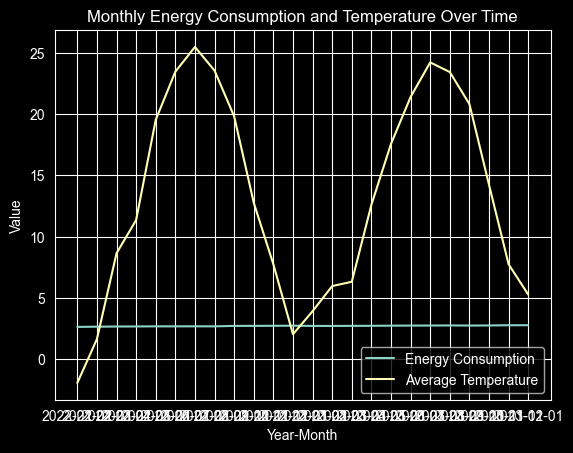

In [98]:
monthly_summary = (
    final_df
    .groupby('year_month', as_index=False)
    .agg({
        'energy_consumption': 'mean',
        'avg_temperature': 'mean'
    })
)

plt.figure()
plt.plot(
    monthly_summary['year_month'],
    monthly_summary['energy_consumption'],
    label="Energy Consumption"
)
plt.plot(
    monthly_summary['year_month'],
    monthly_summary['avg_temperature'],
    label="Average Temperature"
)

plt.xlabel("Year-Month")
plt.ylabel("Value")
plt.title("Monthly Energy Consumption and Temperature Over Time")
plt.legend()
plt.show()